In [ ]:
!pip install transformers torch torchvision supervision pillow opencv-python-headless -q
print("✅ All libraries installed!")

✅ All libraries installed!


In [ ]:
import torch
import numpy as np
import cv2
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from google.colab import files
from IPython.display import display, Image as IPImage
import os

print(f"✅ Imports done!")
print(f"🖥️ Using: {'GPU (CUDA) ✅ Fast!' if torch.cuda.is_available() else 'CPU ⚠️ Will be slow'}")

✅ Imports done!
🖥️ Using: GPU (CUDA) ✅ Fast!


In [ ]:
# This downloads the Grounding DINO model (~700MB)
# It only downloads ONCE, then it's cached

print("⏳ Loading AI model... please wait...")

MODEL_ID = "IDEA-Research/grounding-dino-tiny"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(DEVICE)
model.eval()  # Set to evaluation mode

print("✅ Grounding DINO model loaded successfully!")
print(f"✅ Running on: {DEVICE.upper()}")

⏳ Loading AI model... please wait...


Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

✅ Grounding DINO model loaded successfully!
✅ Running on: CUDA


In [ ]:
def detect_trees(image_path, confidence_threshold=0.30):
    """
    Detects coconut trees in an image using AI.

    Parameters:
    - image_path: path to your uploaded image
    - confidence_threshold: how confident AI must be (0.0 to 1.0)
      Lower = detects more trees but may have false positives
      Higher = more accurate but may miss some trees
    """

    # ── STEP A: Load the image ──────────────────────────────────────────
    image = Image.open(image_path).convert("RGB")
    img_width, img_height = image.size
    print(f"📷 Image loaded: {img_width} x {img_height} pixels")

    # ── STEP B: Tell the AI what to look for ────────────────────────────
    # You can add more text prompts separated by periods
    TEXT_PROMPT = "coconut tree. palm tree. coconut palm."

    # ── STEP C: Process image through the model ──────────────────────────
    inputs = processor(
        images=image,
        text=TEXT_PROMPT,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():  # Don't calculate gradients (saves memory)
        outputs = model(**inputs)

    # ── STEP D: Extract detection results ────────────────────────────────
    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=[(img_height, img_width)]
    )

    detections = results[0]
    boxes  = detections["boxes"].cpu().numpy()   # Bounding box coordinates
    scores = detections["scores"].cpu().numpy()  # Confidence scores
    labels = detections["labels"]                # Detected labels

    # ── Filter detections by confidence threshold ────────────────────────
    keep = scores >= confidence_threshold
    boxes = boxes[keep]
    scores = scores[keep]
    labels = [labels[i] for i, k in enumerate(keep) if k] # Filter labels based on 'keep'

    # ── STEP E: Draw results on the image ────────────────────────────────
    img_array = np.array(image)  # Convert PIL image to numpy array for OpenCV

    for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
        x1, y1, x2, y2 = map(int, box)

        # Draw green bounding box
        cv2.rectangle(img_array, (x1, y1), (x2, y2), (0, 200, 50), 2)

        # Write label and confidence score above the box
        label_text = f"#{i+1} {label} {score:.0%}"
        text_y = max(y1 - 8, 15)  # Make sure text doesn't go off screen
        cv2.putText(
            img_array,
            label_text,
            (x1, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,        # Font size
            (0, 200, 50),  # Green color
            2           # Thickness
        )

    # ── STEP F: Add total count banner at the top ────────────────────────
    tree_count = len(boxes)
    banner_text = f"COCONUT TREES DETECTED: {tree_count}"

    # Black background for text banner
    cv2.rectangle(img_array, (0, 0), (img_width, 45), (0, 0, 0), -1)
    cv2.putText(
        img_array,
        banner_text,
        (10, 32),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.1,
        (0, 255, 100),  # Bright green
        2
    )

    # ── STEP G: Save the output image ────────────────────────────────────
    original_name = os.path.splitext(os.path.basename(image_path))[0]
    output_filename = f"DETECTED_{original_name}.jpg"

    # Convert RGB back to BGR (OpenCV uses BGR)
    cv2.imwrite(output_filename, cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR))

    return output_filename, tree_count, scores

✅ Imports done!
🖥️ Using: GPU (CUDA) ✅ Fast!
⏳ Loading AI model... please wait...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

✅ Grounding DINO model loaded successfully!
✅ Running on: CUDA
📸 COCONUT TREE DETECTOR

👇 Click 'Choose Files' below and upload your aerial image



Saving 20240222fa59a3ef35c1463188255245350eb6e3_202402221cae82d9e09e49a099b1cefda7a45fab.jpg to 20240222fa59a3ef35c1463188255245350eb6e3_202402221cae82d9e09e49a099b1cefda7a45fab (3).jpg

✅ Got image: 20240222fa59a3ef35c1463188255245350eb6e3_202402221cae82d9e09e49a099b1cefda7a45fab (3).jpg
🔍 Running AI detection...
(This takes 10-30 seconds depending on image size)

📷 Image loaded: 1024 x 768 pixels
🌴 RESULT: 12 coconut/palm tree(s) detected
📊 Confidence scores: ['37%', '37%', '39%', '45%', '37%', '34%', '33%', '33%', '30%', '32%', '31%', '32%']
📊 Average confidence: 35%

🖼️ Result image:


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


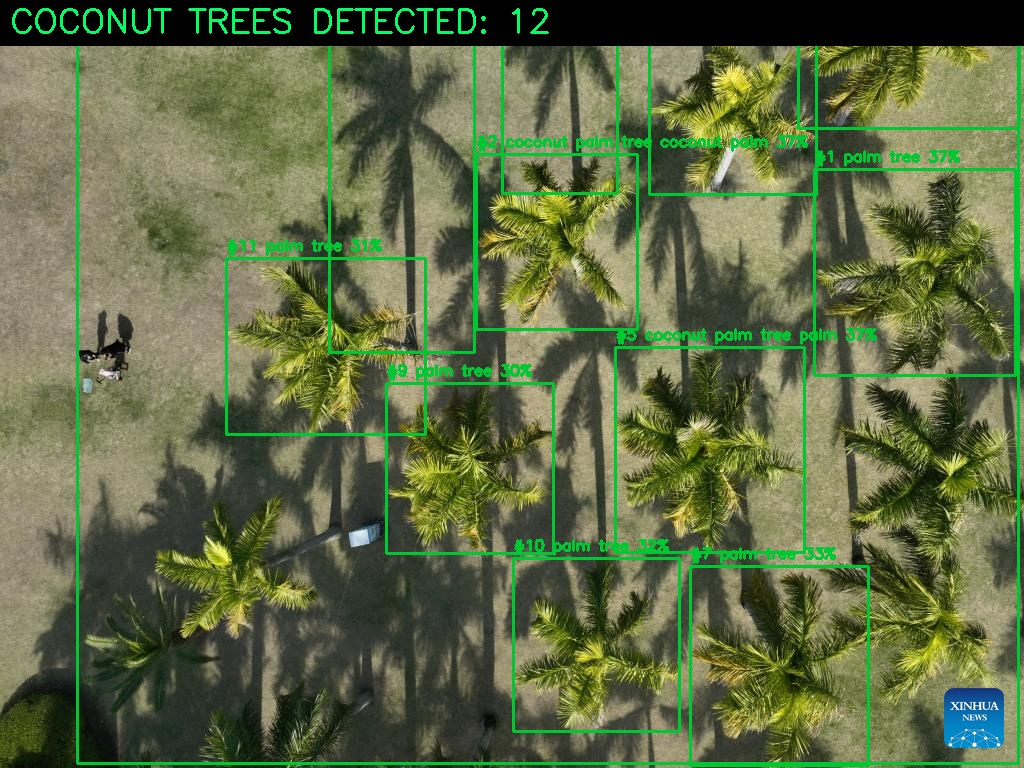

In [ ]:
import torch
import numpy as np
import cv2
from PIL import Image
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from google.colab import files
from IPython.display import display, Image as IPImage
import os

print(f"✅ Imports done!")
print(f"🖥️ Using: {'GPU (CUDA) ✅ Fast!' if torch.cuda.is_available() else 'CPU ⚠️ Will be slow'}")

print("⏳ Loading AI model... please wait...")

MODEL_ID = "IDEA-Research/grounding-dino-tiny"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(DEVICE)
model.eval()  # Set to evaluation mode

print("✅ Grounding DINO model loaded successfully!")
print(f"✅ Running on: {DEVICE.upper()}")

def detect_trees(image_path, confidence_threshold=0.30):
    """
    Detects coconut trees in an image using AI.

    Parameters:
    - image_path: path to your uploaded image
    - confidence_threshold: how confident AI must be (0.0 to 1.0)
      Lower = detects more trees but may have false positives
      Higher = more accurate but may miss some trees
    """

    # ── STEP A: Load the image ──────────────────────────────────────────
    image = Image.open(image_path).convert("RGB")
    img_width, img_height = image.size
    print(f"📷 Image loaded: {img_width} x {img_height} pixels")

    # ── STEP B: Tell the AI what to look for ────────────────────────────
    # You can add more text prompts separated by periods
    TEXT_PROMPT = "coconut tree. palm tree. coconut palm."

    # ── STEP C: Process image through the model ──────────────────────────
    inputs = processor(
        images=image,
        text=TEXT_PROMPT,
        return_tensors="pt"
    ).to(DEVICE)

    with torch.no_grad():  # Don't calculate gradients (saves memory)
        outputs = model(**inputs)

    # ── STEP D: Extract detection results ────────────────────────────────
    results = processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        target_sizes=[(img_height, img_width)]
    )

    detections = results[0]
    boxes  = detections["boxes"].cpu().numpy()   # Bounding box coordinates
    scores = detections["scores"].cpu().numpy()  # Confidence scores
    labels = detections["labels"]                # Detected labels

    # ── Filter detections by confidence threshold ────────────────────────
    keep = scores >= confidence_threshold
    boxes = boxes[keep]
    scores = scores[keep]
    labels = [labels[i] for i, k in enumerate(keep) if k] # Filter labels based on 'keep'

    # ── STEP E: Draw results on the image ────────────────────────────────
    img_array = np.array(image)  # Convert PIL image to numpy array for OpenCV

    for i, (box, score, label) in enumerate(zip(boxes, scores, labels)):
        x1, y1, x2, y2 = map(int, box)

        # Draw green bounding box
        cv2.rectangle(img_array, (x1, y1), (x2, y2), (0, 200, 50), 2)

        # Write label and confidence score above the box
        label_text = f"#{i+1} {label} {score:.0%}"
        text_y = max(y1 - 8, 15)  # Make sure text doesn't go off screen
        cv2.putText(
            img_array,
            label_text,
            (x1, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,        # Font size
            (0, 200, 50),  # Green color
            2           # Thickness
        )

    # ── STEP F: Add total count banner at the top ────────────────────────
    tree_count = len(boxes)
    banner_text = f"COCONUT TREES DETECTED: {tree_count}"

    # Black background for text banner
    cv2.rectangle(img_array, (0, 0), (img_width, 45), (0, 0, 0), -1)
    cv2.putText(
        img_array,
        banner_text,
        (10, 32),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.1,
        (0, 255, 100),  # Bright green
        2
    )

    # ── STEP G: Save the output image ────────────────────────────────────
    original_name = os.path.splitext(os.path.basename(image_path))[0]
    output_filename = f"DETECTED_{original_name}.jpg"

    # Convert RGB back to BGR (OpenCV uses BGR)
    cv2.imwrite(output_filename, cv2.cvtColor(img_array, cv2.COLOR_RGB2BGR))

    return output_filename, tree_count, scores

print("=" * 50)
print("📸 COCONUT TREE DETECTOR")
print("=" * 50)
print("\n👇 Click 'Choose Files' below and upload your aerial image\n")

# ── Upload the image ──────────────────────────────────────────────────────
uploaded = files.upload()

if not uploaded:
    print("❌ No file uploaded. Please run this cell again and upload an image.")
else:
    for filename, content in uploaded.items():
        print(f"\n✅ Got image: {filename}")
        print("🔍 Running AI detection...")
        print("(This takes 10-30 seconds depending on image size)\n")

        # ── Run detection ────────────────────────────────────────────────
        output_file, count, scores = detect_trees(
            filename,
            confidence_threshold=0.30  # ← Adjust this if needed (see tips below)
        )

        # ── Print summary ────────────────────────────────────────────────
        print("=" * 50)
        print(f"🌴 RESULT: {count} coconut/palm tree(s) detected")
        if count > 0:
            print(f"📊 Confidence scores: {[f'{s:.0%}' for s in scores]}")
            print(f"📊 Average confidence: {scores.mean():.0%}")
        print("=" * 50)

        # ── Show the result image ────────────────────────────────────────
        print("\n🖼️ Result image:")
        display(IPImage(output_file, width=800))